In [ ]:
"""2. Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset. a. 
Perform Data Pre-processing b. Define Model and perform training c. Evaluate Results using confusion 
matrix."""


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [8]:
print("Dataset Loaded Successfully")
print("Training Shape:", X_train.shape)

Dataset Loaded Successfully
Training Shape: (60000, 28, 28)


In [9]:
# Reshape to add channel dimension (28x28x1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [10]:
# Normalize pixel values (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
# Convert labels to categorical (One-Hot Encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [12]:
model = Sequential()

In [13]:
# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

C:\Users\Aarya\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

In [15]:
# Flatten Layer
model.add(Flatten())

In [16]:
# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

In [17]:
# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test_cat)
)

print("Model Training Completed")

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9285 - loss: 0.2376 - val_accuracy: 0.9833 - val_loss: 0.0492
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9753 - loss: 0.0844 - val_accuracy: 0.9886 - val_loss: 0.0337
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9823 - loss: 0.0618 - val_accuracy: 0.9903 - val_loss: 0.0287
Model Training Completed


In [20]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9903 - loss: 0.0287
Test Accuracy: 0.9902999997138977


In [21]:
# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


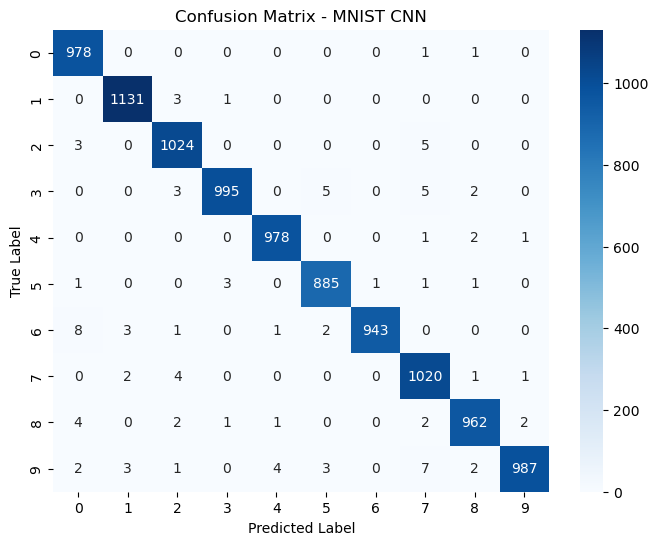

In [22]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST CNN")
plt.show()


In [23]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_classes))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

